![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Isadora Madrid Espinoza

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis** (30%), **Construcción del Modelo** (40%) y **Despliegue del Modelo** (30%). Este notebook corresponde a la **Parte 2 - Construcción del Modelo**, y asume que ya completaste la **Parte 1 - Informe de Análisis**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Solo se evalúa **lo que implementas y respondes**; el **código y los recursos entregados no tienen puntaje**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Preparación** | 5 preguntas conceptuales (0.1 c/u) | 0.5 |
| **2 — Introducción a la Experimentación** | 3 preguntas (0.2 c/u) | 0.6 |
| **3 — Barrido de Combinaciones** | 10 experimentos (0.2 c/u) = 2.0 · preguntas LogReg 0.9 · Árbol/RF 0.2 · LightGBM 0.4 · MLP 0.4 | 3.9 |
| **4 — Selección del Mejor Modelo** | 5 preguntas (0.2 c/u) | 1.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

> El puntaje de cada pregunta y experimento aparece **inline** como `(0.X pts)`.

Esta nota corresponde a la nota de la **Parte 2** que equivale a un **40%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| **2 — Modelo**     | **40%**     |
| 3 — Despliegue     | 30%         |


## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 2 - Construcción del Modelo

En la Parte 1 entendiste el problema y exploraste los datos. Recapitulemos lo que ya sabemos y que guiará todo este notebook:

- El problema es de **clasificación multiclase**: predecir `Nivel_Prioridad` ∈ {`Baja`, `Media`, `Alta`, `Critica`}.
- Las clases están **desbalanceadas** (Media ~39%, Baja ~36%, Alta ~17%, Critica ~7%).
- La variable `Tiempo_de_Resolución_Horas` es **data leakage** (no está disponible en inferencia), así que **no la usaremos**.
- Contamos con features de **texto** (`Asunto_Ticket`, `Contenido_Ticket`), **categóricas** (`Canal_Ticket`, `Categoría_Problema`), una **numérica** (`N_Caracteres_Ticket`) y los **embeddings** (`gemini-embedding-001`, 1024 dimensiones).
- Siguiendo la decisión de la Parte 1, la **métrica a optimizar será el _macro recall_** (promedio simple del recall por clase), para no descuidar a la clase `Critica`.

La idea de esta parte es experimentar con muchas combinaciones de **(features × modelo)**, optimizando los hiperparámetros con **Optuna** y registrando todo en **MLflow**, para finalmente elegir y exportar el mejor.

> **MLflow**: usaremos MLflow para *experiment tracking*. Como MLflow 3.x deprecó el backend de archivos, usaremos un backend de base de datos local (`sqlite:///mlflow.db`). Si no lo tienes instalado:
> ```bash
> uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk
> ```
> Para abrir la interfaz gráfica y comparar tus runs:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```

---

# Sección 1 - Preparación — (0.5 pts)

Antes de modelar, dejaremos listo el **protocolo experimental**: definir el split y la métrica y el ejecutor de experimentos antes de ejecutar cualquier experimento.

> Este código será dado, por ende, no tendrá puntaje.

Tareas de esta sección:

1. Importar librerías, configurar MLflow (tracking URI + experimento)., fijar semillas y definir las **constantes compartidas**.
2. Cargar `tickets.parquet` y `embeddings.parquet`. Descartar el *data leakage*, contruir una única columna de texto y armar un **único** dataframe `X_full` que contenga las features tabulares, el texto y las 1024 columnas de embedding.
3. Separar en **train / val / test (60/20/20) estratificado**.

In [1]:
# ------------ 1. Importar librerías, fijar semillas y configurar constantes ------------

import re

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
try:
    mlflow.create_experiment("ProyectoMDS7202")
except:
    print("El experimento ya existe")
mlflow.set_experiment("ProyectoMDS7202")

# Definir constantes y fijar semillas
SEED = 42

np.random.seed(SEED)

ORDEN_CLASES = ["Baja", "Media", "Alta", "Critica"]
NUM_COLS = ["N_Caracteres_Ticket"]
CAT_COLS = ["Canal_Ticket", "Categoría_Problema"]
TEXT_COL = "Texto"

# ------------ 2. Cargar y preprocesar los datos ------------

# Cargar datos tabulares
df = pd.read_parquet("data/tickets.parquet")

# Descartamos la variable con data leakage detectada en la Parte 1
df = df.drop(columns=["Tiempo_de_Resolución_Horas"])

# Combinar campos de texto en una sola columna "Texto"
df["Texto"] = df["Asunto_Ticket"].fillna("") + " " + df["Contenido_Ticket"].fillna("")

# Cargar Embeddings (mismo orden de filas que df).
embeddings = pd.read_parquet("data/embeddings.parquet")
EMBEDDING_COLS = list(embeddings.columns)

# Generar único dataframe con todas las variables: tabular + texto + embeddings.
X_full = pd.merge(
    df.drop(columns=["Nivel_Prioridad", "Asunto_Ticket", "Contenido_Ticket"]),
    embeddings,
    on="Id_Ticket",
).drop(columns=["Id_Ticket"])
y = df["Nivel_Prioridad"]

print("---------- EDA Breve ----------\n")
print("X_full:", X_full.shape, "| columnas de embedding:", len(EMBEDDING_COLS))
print("Clases:", sorted(y.unique()))
display(X_full.head(10))
display(y.head(10))
display((y.value_counts() / len(y)).mul(100).round(2).rename("Distribución Labels (%)", inplace=True))

c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/07/10 14:45:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/10 14:45:31 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migrat

---------- EDA Breve ----------

X_full: (2000, 1031) | columnas de embedding: 1024
Clases: ['Alta', 'Baja', 'Critica', 'Media']


,N_Caracteres_Ticket,Canal_Ticket,Categoría_Problema,Usuario-Tipo_de_Cuenta,Usuario-Antiguedad_Cuenta_Dias,Fecha_Envío,Texto,embedding_dim_1,embedding_dim_2,embedding_dim_3,...,embedding_dim_1015,embedding_dim_1016,embedding_dim_1017,embedding_dim_1018,embedding_dim_1019,embedding_dim_1020,embedding_dim_1021,embedding_dim_1022,embedding_dim_1023,embedding_dim_1024
0,531,Whatsapp,Cuenta,Premium,159,2024-01-02,Error al iniciar sesión en nuevo celular por d...,-0.011585,-0.008728,0.012878,...,-0.011539,-0.016249,0.004422,-0.022274,0.004511,0.001428,-0.007812,-0.020485,-0.001888,-0.000408
1,784,Whatsapp,Otro,Premium,192,2024-01-02,Error al actualizar correo electrónico: bloque...,0.014494,0.004070,0.011298,...,-0.019967,-0.008424,-0.002084,-0.002761,-0.004148,-0.007131,-0.012717,-0.019045,-0.015172,0.004308
2,600,Whatsapp,Fraude,Free,314,2024-01-02,Cobro desconocido en mi tarjeta digital Hola b...,-0.010936,0.020796,0.011680,...,-0.021763,-0.007094,-0.011453,-0.001084,-0.005820,-0.015085,0.003200,-0.019789,-0.018502,-0.001085
3,659,Whatsapp,Cuenta,Free,228,2024-01-02,"Cuenta bloqueada sin aviso, necesito ayuda urg...",0.003248,0.005420,0.003422,...,-0.019830,-0.007490,-0.013525,0.000086,-0.011983,0.007148,-0.002536,-0.016200,-0.003927,-0.004028
4,853,Whatsapp,Otro,Free,72,2024-01-03,Me descontaron plata del cajero y no salió el ...,-0.010437,0.013634,0.009859,...,-0.006401,-0.001971,0.002344,-0.010598,-0.011034,-0.012039,-0.000857,-0.009420,-0.006597,0.012463
5,672,Whatsapp,Otro,Free,71,2024-01-03,Problemas con retiro en cajero y saldo retenid...,-0.006699,0.015320,0.004916,...,-0.002004,-0.009383,0.002027,-0.004618,-0.005886,0.001436,-0.002760,-0.010959,-0.019190,0.013137
6,691,Correo,Cuenta,Free,27,2024-01-03,Problema con transferencia no recibida: dinero...,-0.001424,0.013316,-0.001574,...,-0.017849,0.000331,-0.004115,-0.007396,-0.016886,-0.004226,0.000309,-0.011096,-0.009890,0.001992
7,782,Whatsapp,Técnica,Free,193,2024-01-05,Error al acceder a la sección de inversiones (...,-0.001278,0.014927,0.002564,...,-0.021633,-0.006482,0.000185,-0.000037,-0.001324,-0.010792,0.003312,-0.020291,-0.002917,-0.004307
8,652,Página Web,Técnica,Free,283,2024-01-05,"Error en transferencia y saldo descontado, ayu...",0.003861,-0.008191,0.009408,...,-0.009119,-0.002006,0.003867,-0.010697,-0.020366,-0.003357,0.003855,-0.027547,-0.014218,0.010238
9,427,Whatsapp,Pregunta general,Free,72,2024-01-05,duda con inversiones y error en la app hola bu...,-0.010484,0.003417,0.022390,...,-0.016919,-0.004394,-0.004335,-0.009940,0.002788,-0.003919,0.001589,-0.023548,-0.008324,-0.010632


0     Baja
1    Media
2     Baja
3    Media
4    Media
5    Media
6    Media
7    Media
8    Media
9     Baja
Name: Nivel_Prioridad, dtype: object

Nivel_Prioridad
Media      39.45
Baja       36.15
Alta       17.50
Critica     6.90
Name: Distribución Labels (%), dtype: float64

In [2]:
# ------------ 3. Split train/val/test ------------

print("---------- Splits ----------\n")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_full,
    y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=SEED,
)

print("Elementos por set | Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
d_y_train = (
    (y_train.value_counts() / len(y_train)).mul(100).round(2).rename("Distribución Labels Train (%)", inplace=True)
)
d_y_val = (y_val.value_counts() / len(y_val)).mul(100).round(2).rename("Distribución Labels Val (%)", inplace=True)
d_y_test = (y_test.value_counts() / len(y_test)).mul(100).round(2).rename("Distribución Labels Test (%)", inplace=True)
display(pd.concat([d_y_train, d_y_val, d_y_test], axis=1))

---------- Splits ----------

Elementos por set | Train: 1200 | Val: 400 | Test: 400


,Distribución Labels Train (%),Distribución Labels Val (%),Distribución Labels Test (%)
Nivel_Prioridad,,,
Media,39.42,39.5,39.50
Baja,36.17,36.0,36.25
Alta,17.50,17.5,17.50
Critica,6.92,7.0,6.75


Antes de modelar, responde:

1. ¿Por qué fijamos el split (train/val/test) **antes** de entrenar cualquier modelo? ¿Qué riesgo evitamos? **(0.1 pts)**
2. En general, siempre vamos a utilizar el enfoque de optimización de hiperparámetros. ¿Por qué utilizar train/val/test y no solo train/test es importante? ¿Qué otra técnica hay para evitar esto? **(0.1 pts)**
3. ¿Por qué usamos un split **estratificado**? ¿qué problema causaría un split aleatorio en val/test asumiendo que para esta cantidad de datos, la métricas pueden ser ruidosas? Apoya tu respuesta ejecutando el bloque `Split train/val/test` de la celda anterior comentando el parámetro `stratify` y justifica usando los resultados obtenidos. Luego, recuerda volver a agregar el parámetro, de lo contrario, tus resultados se podrían ver afectados. **(0.1 pts)**
4. ¿Por qué la métrica adecuada aquí es el **macro recall** y no, por ejemplo, el _accuracy_? Conéctalo con el desbalance y con lo que respondiste en la Parte 1. **(0.1 pts)**
5. ¿Qué es el **experiment tracking** y qué ganamos al registrar cada modelo en MLflow en lugar de solo imprimir métricas? Piensa en qué pasa si reinicias, por ejemplo, el notebook de Jupyter. **(0.1 pts)**

_Subtotal preguntas: 0.5 pts_

**Responde aquí**

> 1. Fijamos el split para establecer un protocolo experimental claro y evitar que las decisiones del modelamiento se vean influenciadas por el conjunto de evaluación. De esta forma, todos los modelos se comparan usando exactamente los mismos datos de entrenamiento, validación y test. El riesgo que evitamos es la fuga de información. Si el split se definiera después de entrenar o ajustar modelos, podríamos contaminar indirectamente la evaluación y obtener métricas demasiado optimistas.

> 2. Usamos train/val/test porque en esta parte vamos a optimizar hiperparámetros. El conjunto de entrenamiento se usa para ajustar el modelo, el conjunto de validación se usa para comparar distintas configuraciones, y el conjunto de test se utiliza para la evaluación final. En caso de que decidieramos usar solo train/test, terminaríamos eligiendo hiperparámetros mirando repetidamente el desempeño en test, eso haría que el test dejara de ser una evaluación imparcial, porque el modelo quedaría ajustado a ese conjunto. Otra técnica para evitar este problema es la validación cruzada, donde se generan varios splits de entrenamiento y validación para evaluar de forma más robusta.

> 3. Usamos un split estratificado porque la variable objetivo está desbalanceada. En la base completa, las clases tienen aproximadamente esta distribución:

> |Clase | Porcentaje|
> | --- | --- | 
> |Media	| 39.45%|
> |Baja | 36.15%|
> |Alta | 17.50%|
> |Critica | 6.90%|

> Como "Critica" es una clase minoritaria, un split completamente aleatorio podría dejar muy pocos casos críticos en validación o test. Eso haría que las métricas fueran más inestables y ruidosas. Con el split estratificado, las proporciones se mantienen casi iguales:
>|Clase|	Train|	Val|	Test|
>| --- | --- | --- | --- |  
>|Media|	39.42%|	39.50%|	39.50%|
>|Baja|	36.17%|	36.00%|	36.25%|
>|Alta|	17.50%|	17.50%|	17.50%|
>|Critica|	6.92%|	7.00%|	6.75%|

>Esto confirma que el split estratificado conserva la distribución de clases en los tres conjuntos y permite evaluar el modelo de manera más representativa.

> 4. La métrica adecuada es macro recall porque el problema tiene clases desbalanceadas y porque, desde el punto de vista del negocio, es muy importante detectar correctamente los tickets de prioridad Alta y Critica. Si usáramos solo accuracy, un modelo podría obtener buen resultado clasificando bien las clases mayoritarias, como Baja y Media, pero fallar en la detección de tickets críticos. Esto sería problemático para el negocio porque justamente los tickets críticos son los que requieren atención más urgente. El macro recall calcula el recall de cada clase y luego promedia todas las clases con el mismo peso. Por eso, no deja que las clases mayoritarias dominen la métrica y permite evaluar mejor si el modelo detecta adecuadamente también las clases menos frecuentes.

> 5. El experiment tracking consiste en registrar ordenadamente cada experimento realizado durante el modelamiento. Usar MLflow es útil porque permite comparar experimentos de forma sistemática. En lugar de depender solo de métricas impresas en el notebook, que pueden perderse si se reinicia Jupyter, por ejemplo, o si se ejecutan muchas celdas, MLflow guarda cada corrida como un registro separado. 
> Esto facilita identificar qué combinación de features, modelo e hiperparámetros obtuvo el mejor resultado, además de mejorar la trazabilidad y reproducibilidad del proyecto.

---

# Sección 2 - Introducción a la Experimentación — (0.6 pts)

La idea de la experimentación de este lab es que puedan probar muchas combinaciones de modelos y subconjuntos de features para resolver el problema.
Para no repetir el código de `Optuna` + `MLflow` una y otra vez, encapsularemos todo en **dos clases (ejecutor de experimentos y experimento abstracto) las cuales se te serán provistas**.

La idea de esta abstracción es finalmente que ustedes no definan el cómo ejecutan el experimento (código muy estándar), si no que simplemente definan la pipeline y el espacio de hiperparámetros a probar. 

- **`AbstractExperiment`**: define el *contrato* de un experimento. Cada experimento que ustedes hagan debe ser una **subclase** que implemente estos 4 métodos:
  - `model_name` (propiedad): Nombre del modelo a probar. Sirve para identificar el run.
  - `feature_set` (propiedad): Subconjunto de features a utilizar. Sirve para identificar el run.
  - `build_pipeline(hparams) -> Pipeline`: construye tu `ColumnTransformer` + modelo, parametrizado por `hparams`.
  - `generate_trial_hparams(trial) -> dict`: define el espacio de búsqueda de Optuna.
  
Mas adelante habrá un ejemplo de cómo implementar esto.

- **`ExperimentExecutor`**: recibe un experimento y se encarga del resto: corre **Optuna** (optimizando macro recall en **val**, cada *trial* como run anidado en MLflow), reentrena la mejor configuración con **train+val** y la evalúa en **test**, registrando todo en MLflow.

Esto nos garantiza que todos los modelos se comparen con el mismo protocolo.

In [6]:
from __future__ import annotations
import abc

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
from optuna.integration.mlflow import MLflowCallback
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    recall_score,
)
from sklearn.pipeline import Pipeline


class AbstractExperiment(abc.ABC):
    """Experimento Abstracto.

    Permite que más adelante definan los experimentos a ejecutar.
    """

    @property
    @abc.abstractmethod
    def model_name(self) -> str:
        """Nombre del modelo, p.ej. 'Regresión_Logística', 'Arbol_de_Decision', 'LightGBM'..."""
        raise NotImplementedError()

    @property
    @abc.abstractmethod
    def feature_set(self) -> str:
        """Identificador del conjunto de features: 'Base', 'BoW', 'Embeddings', 'Todo', ..."""
        raise NotImplementedError()

    @property
    def study_name(self) -> str:
        """Identidad única de la combinación modelo × features. - Esta no debe ser redefinida"""
        return f"{self.model_name}__{self.feature_set}"

    @abc.abstractmethod
    def build_pipeline(self, hparams: dict) -> Pipeline:
        """Construye la pipeline a partir de los hiperparámetros entregados por Optuna.

        En este método deberán generar tanto el ColumnTransformer, como también el Pipeline,
        basándose en los parámetros entregados en hparams y dejando fijo el resto.
        Luego, deben retornar el Pipeline generado.
        """
        raise NotImplementedError()

    @abc.abstractmethod
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        """Genera los hiperparámetros a partir del trial de optuna que permitirán construir el pipeline.

        En este método deberán retornar un diccionario con los hiperparámetros generados por Optuna
        que luego, permitirán construir el Pipeline.

        Ejemplo:
        ```python
        return {"C": trial.suggest_float("C", 1e-3, 1e2, log=True)}
        ```
        """

        raise NotImplementedError()


class ExperimentExecutor:
    """Ejecutor de experimentos.

    Esta clase permite ejecutar un experimento de forma estandarizada y luego logear sus resultados a MLFlow.

    NO MODIFICAR.
    """

    def refit_and_eval_with_test(
        self,
        experiment: AbstractExperiment,
        best_params: dict,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        run_name: str,
        parent_run_id = None,
    ) -> float:
        """Reentrena con train+val la mejor config, evalúa en test (macro recall).

        Registra params/métricas/matriz de confusión/classification report en MLflow
        y devuelve el macro recall de test.
        """

        X_train_final = pd.concat([X_train, X_val], axis=0)
        y_train_final = pd.concat([y_train, y_val], axis=0)
        trained_pipeline = experiment.build_pipeline(best_params).fit(X_train_final, y_train_final)

        # evalúa sobre el conjunto con el que realmente se entrenó
        y_train_pred = trained_pipeline.predict(X_train_final)
        y_test_pred = trained_pipeline.predict(X_test)

        mr_final_train = float(recall_score(y_train_final, y_train_pred, average="macro"))
        mr_test = float(recall_score(y_test, y_test_pred, average="macro"))

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("stage", "refit_final")
            mlflow.set_tag("study_name", experiment.study_name)
            # tags estructurados para agrupar/filtrar en la UI
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)
            if parent_run_id is not None:
                mlflow.set_tag("parent_run_id", parent_run_id)

            if best_params:
                mlflow.log_params(best_params)

            # tamaños de los splits para reproducibilidad
            mlflow.log_params(
                {
                    "n_train": len(X_train),
                    "n_val": len(X_val),
                    "n_train_final": len(X_train_final),
                    "n_test": len(X_test),
                }
            )

            mlflow.log_metric("macro_recall_final_train", mr_final_train)
            mlflow.log_metric("macro_recall_test", mr_test)

            # métricas por clase consultables desde el reporte como dict
            report_dict = classification_report(y_test, y_test_pred, output_dict=True)
            for label, metrics in report_dict.items():
                if isinstance(metrics, dict):
                    safe_label = str(label).replace(" ", "_")
                    mlflow.log_metric(f"recall_test_{safe_label}", metrics["recall"])
                    mlflow.log_metric(f"precision_test_{safe_label}", metrics["precision"])
                    mlflow.log_metric(f"f1_test_{safe_label}", metrics["f1-score"])

            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_test_pred,
                labels=ORDEN_CLASES,
                xticks_rotation=45,
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{run_name} (test)")
            fig.tight_layout()
            mlflow.log_figure(fig, "matriz_confusion_test.png")
            plt.close(fig)

            # --- Permutation importance sobre el modelo refit (evaluada en test) ---
            # Permutamos cada columna de ENTRADA que el modelo realmente usa y medimos la caída
            # del macro recall. Con embeddings son cientos de columnas sin significado individual:
            # la idea es justamente evidenciar que no son interpretables una a una.
            ct_refit = trained_pipeline.steps[0][1]  # ColumnTransformer (1er paso del pipeline)
            used_cols = []
            for _, trans, cols in ct_refit.transformers_:
                if trans == "drop":
                    continue
                used_cols += [cols] if isinstance(cols, str) else list(cols)

            pi = permutation_importance(
                trained_pipeline,
                X_test[used_cols],
                y_test,
                scoring="recall_macro",
                n_repeats=5,
                random_state=SEED,
            )
            top = np.argsort(pi.importances_mean)[-20:]  # top-20 por importancia media
            fig_pi, ax_pi = plt.subplots(figsize=(6, max(3, 0.32 * len(top))))
            ax_pi.barh(
                [used_cols[i] for i in top],
                pi.importances_mean[top],
                xerr=pi.importances_std[top],
                color="#4C72B0",
            )
            ax_pi.set_xlabel("Caída de macro recall al permutar (importancia)")
            ax_pi.set_title(f"Permutation importance — {run_name} (top 20, test)")
            fig_pi.tight_layout()
            mlflow.log_figure(fig_pi, "permutation_importance_test.png")
            plt.close(fig_pi)

            clf_report = classification_report(y_test, y_test_pred, output_dict=False)
            mlflow.log_text(str(clf_report), "classification_report_test.txt")

            signature = mlflow.models.infer_signature(X_train_final, y_test_pred)
            # cloudpickle: el serializador estricto (skops) rechaza el tokenizador propio y joblib.Memory
            mlflow.sklearn.log_model(
                trained_pipeline,
                name="model",
                signature=signature,
                input_example=X_train_final.head(3),
                serialization_format="cloudpickle",
            )

        print(f"{run_name:32s} | Macro recall final_train={mr_final_train:.3f}  test={mr_test:.3f}")
        return mr_test

    def run_experiment(
        self,
        experiment: AbstractExperiment,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        timeout_seconds: int | None,
        n_trials: int | None,
    ):
        """Optimiza con Optuna (cada trial = run anidado en MLflow), reentrena la mejor
        configuración con train+val y la registra en un run de refit.

        NOTA: el experimento de MLflow se fija UNA vez fuera de este método
        (mlflow.set_experiment(...) en la Sección 0), de modo que todas las
        combinaciones modelo x features queden en el mismo experimento y comparables.
        """
        if not isinstance(experiment, AbstractExperiment):
            raise ValueError(
                f"El parámetro experiment debe implementar AbstractExperiment, se entregó: {type(experiment)}"
            )
        if timeout_seconds is not None and not isinstance(timeout_seconds, int):
            raise ValueError(f"timeout_seconds debe ser entero. Entregado: {type(timeout_seconds)}")
        if n_trials is not None and not isinstance(n_trials, int):
            raise ValueError(f"n_trials debe ser entero. Entregado: {type(n_trials)}")
        if (not timeout_seconds) and (not n_trials):
            raise ValueError("Al menos uno de timeout_seconds o n_trials debe ser distinto de nulo.")

        # callback nativo de Optuna: registra cada trial como run anidado
        mlflow_callback = MLflowCallback(
            metric_name="macro_recall_val",
            create_experiment=False,
            mlflow_kwargs={"nested": True},
        )

        with mlflow.start_run(run_name=f"{experiment.study_name}_search") as parent_run:
            parent_run_id = parent_run.info.run_id
            mlflow.set_tag("stage", "optuna_search")
            mlflow.set_tag("study_name", experiment.study_name)
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)

            @mlflow_callback.track_in_mlflow()
            def objective(trial):
                params = experiment.generate_trial_hparams(trial)
                pipe = experiment.build_pipeline(params).fit(X_train, y_train)
                mr_val = float(recall_score(y_val, pipe.predict(X_val), average="macro"))
                mlflow.log_params(params)
                mlflow.set_tag("trial_number", trial.number)
                return mr_val

            study = optuna.create_study(
                direction="maximize",
                study_name=experiment.study_name,
                sampler=optuna.samplers.TPESampler(seed=SEED),
            )
            study.optimize(
                objective,
                timeout=timeout_seconds,
                n_trials=n_trials,
                show_progress_bar=True,
                callbacks=[mlflow_callback],
            )

            # resumen de la búsqueda en el run padre
            mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
            mlflow.log_metric("best_macro_recall_val", float(study.best_value))
            mlflow.log_metric("n_trials_completed", len(study.trials))

            # visualizaciones de Optuna como artefactos del run padre
            try:
                history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
                mlflow.log_figure(history_fig.figure, "optuna_optimization_history.png")
                plt.close(history_fig.figure)

                importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
                mlflow.log_figure(importance_fig.figure, "optuna_param_importances.png")
                plt.close(importance_fig.figure)

                parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
                mlflow.log_figure(parallel_fig.figure, "optuna_parallel_coordinate.png")
                plt.close(parallel_fig.figure)
            except Exception as exc:  # la importancia falla con <2 trials o sin hiperparámetros
                print(f"No se pudieron generar visualizaciones de Optuna: {exc}")

        # refit fuera del run padre, enlazado por tag
        self.refit_and_eval_with_test(
            run_name=experiment.study_name,
            experiment=experiment,
            best_params=study.best_params,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            parent_run_id=parent_run_id,
        )
        return study


# Instanciamos el ejecutor de experimentos.
# Notar que es agnostico al experimento, así que no es necesario instanciarlo nuevamente.
exp_executor = ExperimentExecutor()

### Ejemplo trabajado: Baseline

A continuación entregamos un experimento **completo y comentado** que cumple dos roles: 

1. Ser el **template** que debes adaptar para tus propios experimentos 
2. Ser el **baseline** (una Regresión Logística usando solo las features tabulares). Fíjate en las cuatro piezas que todo experimento debe definir: 
    - `model_name`
    - `feature_set`
    - `build_pipeline`
    - `generate_trial_hparams`.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cache de pipelines: Cachea (guarda) y carga etapas de preprocesamiento para
# no recalcular etapas identicas entre distintas runs
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogisticRegressionWithBaseExperiment(AbstractExperiment):
    """Baseline: Regresión Logística sobre el feature-set base.

    Úsalo como molde para tus propios experimentos.
    """

    # 1. Definir nombre del modelo.
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    # 2. Definir la feature ser que se utilizará (Base, BoW, Embeddings, Full, Base+BoW, etc.)
    @property
    def feature_set(self) -> str:
        return "Base"

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # 3.1. Preprocesamiento: escala las numéricas y codifica las categóricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
            ]
        )
        # 3.2. Modelo: class_weight="balanced" para no ignorar a las clases minoritarias.
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        # 3.3. Pipeline
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # Importante: Debe ir siempre!
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }

In [8]:
# Notar que tenemos los parámetros timeout_seconds y n_trials.
# Optuna se detendrá cuando ocurra el primero de estos.

exp_executor.run_experiment(
    experiment=LogisticRegressionWithBaseExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=50,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
Best trial: 0. Best value: 0.407816:   2%|▏         | 1/50 [00:00<00:30,  1.63it/s, 0.61/60 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarni

Regresión_Logística__Base        | Macro recall final_train=0.543  test=0.493


### Leer y comparar tus experimentos en MLflow

Para abrir la interfaz y comparar tus runs:

> **Importante - El terminal debe estar en la misma carpeta que MLflow**. De lo contrario, no encontrarás ningún resultado.

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Abre el experimento **`ProyectoMDS7202`**. Para comparar las combinaciones (features × modelo):

- En la vista **Table**, agrega como columnas las métricas:
  - `macro_recall_val`: la que optimiza Optuna; vive en los runs `*_search`
  - `macro_recall_test`: la real; vive en los runs de **refit**, `stage=refit_final`.
- Agrupa o filtra por los **tags** `model_name` y `feature_set` para ver una fila por combinación. Filtra por `tags.stage = "refit_final"` para quedarte con los resultados finales.
- **Ordena por `macro_recall_val`** para rankear; y mira también `recall_test_Critica`: de nada sirve un macro alto si la clase crítica queda mal.
- En la vista **Chart** (o *parallel coordinates*) explora cómo cada hiperparámetro afecta el macro recall.
- En cada run de refit, pestaña **Artifacts**, encontrarás `matriz_confusion_test.png` y `classification_report_test.txt`; en el run `*_search`, el historial y la importancia de hiperparámetros de Optuna.

---

**Preguntas**:

1. ¿Qué ventajas tiene encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` en lugar de copiar/pegar el código de Optuna para cada modelo? (piensa en comparación justa, reproducibilidad y errores). **(0.2 pts)**
2. **Sobre el refit.** El ejecutor, tras la búsqueda, reentrena la mejor configuración con **train+val** y la evalúa en **test**. **(0.2 pts)**
   - (a) ¿Por qué reentrenar con `train+val` en vez de quedarnos con el modelo que ya se entrenó solo con `train` durante la búsqueda?
   - (b) Si el ejecutor calculara el `macro_recall_test` de cada experimento y nos quedáramos con este. ¿Sería correcto conceptualmente? ¿Qué riesgo nos implicaría "espiar" los resultados del test de todos los candidatos, y por qué seleccionar solo por val mantiene el problema acotado?
3. Es posible que los resultados de las métricas de test sean menor que las de validación (test < val), incluso, aunque el refit use más datos (train+val). ¿Por qué ocurre esto? (pista: ¿sobre que conjunto optimizamos durante la búsqueda?) **(0.2 pts)**

_Subtotal preguntas: 0.6 pts_

**Responde aquí**

> 1. Encapsular el flujo en ExperimentExecutor y AbstractExperiment permite que todos los experimentos se ejecuten bajo el mismo protocolo. Esto hace que la comparación entre modelos sea más justa, porque todos usan el mismo split, la misma métrica de optimización, la misma lógica de validación y el mismo registro en MLflow.
> Si cada experimento se escribiera manualmente, podrían aparecer diferencias accidentales en el entrenamiento, en la métrica usada o en la forma de registrar los resultados. Con esta estructura, cada nuevo experimento solo debe definir el modelo, el conjunto de features, el pipeline y los hiperparámetros a buscar. Mejora la reproducibilidad, porque los resultados quedan registrados de manera ordenada en MLflow, junto con sus métricas, parámetros y artefactos.

> 2(a). Durante la búsqueda de hiperparámetros, el modelo se entrena con train y se evalúa en val. Una vez que Optuna encuentra la mejor combinación de hiperparámetros, ya no necesitamos seguir usando val para seleccionar el modelo. Por eso, se reentrena el modelo final usando train+val, aprovechando más datos para ajustar la versión definitiva. En el experimento baseline, el modelo final obtuvo un macro_recall_final_train aproximado de 0.54 y un macro_recall_test aproximado de 0.49, lo que muestra que el desempeño final se evalúa recién después del refit.

> 2(b). No sería correcto usar el macro_recall_test para seleccionar entre todos los candidatos, porque eso implicaría “espiar” el conjunto de test. El test debe funcionar como una evaluación final e imparcial, no como parte del proceso de selección. Si miramos el resultado en test de todos los modelos y elegimos el mejor según ese valor, el modelo quedaría indirectamente ajustado al test. Esto generaría una estimación demasiado optimista del desempeño real. Por eso, la selección debe hacerse con val, usando métricas como macro_recall_val, y recién al final se evalúa una única vez en test.

> 3. Es posible que las métricas de test sean menores que las de validación porque durante la búsqueda de hiperparámetros el modelo se optimiza sobre el conjunto de validación. Optuna prueba muchas combinaciones y selecciona la que obtiene mejor desempeño en val. En cambio, el conjunto de test no participa en la optimización ni en la selección de hiperparámetros. Por lo tanto, entrega una evaluación más exigente y realista. En el baseline se observa justamente esto, durante la búsqueda se alcanzó un mejor valor de validación cercano a 0.553, mientras que el resultado final en test fue aproximadamente 0.493.
> Esto no significa que el modelo esté mal, puede que el desempeño en validación sea más optimista porque fue el conjunto usado para seleccionar la mejor configuración. El test representa mejor cómo podría comportarse el modelo frente a datos no vistos.

---

# Sección 3 - Barrido de Combinaciones (features × modelo) — (3.9 pts)

Ahora que ya entendiste y experimentaste sobre el template, vamos a comenzar el proceso de experimentación.

Implementa una **subclase de `AbstractExperiment` por cada combinación (features × modelo)** y córrela con `exp_executor.run_experiment(...)`. **Cada combinación va en su propia subsección** (`3.1`, `3.2`, …) con su clase y su ejecución.

Iremos recorriendo distintas **familias de modelos**. Para cada una probaremos los feature-sets que tienen sentido según cómo ese modelo "consume" la información:

1. **Regresión Logística** (modelo lineal). La probaremos sobre 4 feature-sets para medir qué representación aporta más señal:
   - `Bow`: Bag of Words + Stemming + Stopwords.
   - `Base+Bow`: features tabulares (numérica + categóricas) + BoW.
   - `Embeddings`.
   - `Todo`: tabular + BoW + embeddings.
2. **Árbol de Decisión** y **Random Forest** (*bagging*), cada uno sobre `Base+Bow`: contrastaremos modelos de cortes *axis-aligned* contra el lineal, usando el mismo texto + tabular.
3. **LightGBM** (*boosting*), una subsección por feature-set (`Bow`, `Embeddings` y `Todo`): veremos cómo se comporta el boosting según el tipo de representación (dispersa de BoW vs densa de embeddings).
4. **Red Neuronal (MLP)** sobre `Embeddings`, a modo **demostrativo**: si una red aprovecha la representación densa de los embeddings.

---

### 📝 [Paréntesis] Texto a features: Bag-of-Words + Stemming + Stopwords

Varios de los siguientes experimentos usan **texto**. Para que un modelo lo consuma, lo convertimos en números con **Bag-of-Words (BoW)**: se arma un vocabulario y cada ticket se representa por un vector con la **frecuencia de cada término** (se ignora el orden de las palabras). Antes de contar aplicamos dos limpiezas estándar:

- **Stemming**: reduce cada palabra a su **raíz**, colapsando variantes (`"pagos"`, `"pagar"`, `"pagó"` → `"pag"`). Así el vocabulario es más chico y la señal queda más concentrada. Usaremos el `SnowballStemmer` en español.
- **Stopwords**: elimina palabras **muy frecuentes y sin señal** (`"de"`, `"la"`, `"que"`, ...) que solo agregan ruido y dimensión.

El tamaño del vocabulario lo controla `max_features` del `CountVectorizer`, y lo trataremos como **un hiperparámetro más** a optimizar. Te entregamos el tokenizador (stemming + stopwords) ya armado.

> 💡 _cache_ de pipelines para BoW.** El preprocesamiento del texto es lo más **caro** del pipeline. Si le pasas `memory=memoria` a tu `Pipeline`, sklearn **cachea los transformadores ya ajustados**: cuando entre dos *trials* de Optuna se repite la **misma** configuración de preprocesamiento (mismo `max_features`, mismas columnas), no se recalcula, se lee del cache. _Matiz_: como `max_features` es un hiperparámetro, el cache ayuda sobre todo cuando se repite un valor de `max_features`, o cuando entre trials solo cambian hiperparámetros del **modelo**.

In [13]:
# --- Código dado: tokenizador (stemming + stopwords) y cache de pipelines ---
import re

import joblib
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Tokenizador en español: minúsculas -> tokens -> quita stopwords -> stemming.
# Es una función a nivel de módulo (no un lambda) para que joblib pueda cachearla.
stemmer = SnowballStemmer("spanish")
patron_token = re.compile(r"(?u)\b\w\w+\b")
stopwords_es = set(stopwords.words("spanish"))


def tokenizador_stemming(texto):
    tokens = patron_token.findall(texto.lower())
    return [stemmer.stem(t) for t in tokens if t not in stopwords_es]


## 3.1. Regresión Logística + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando **BoW**. Deja fuera todo el resto de features.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [15]:
class LogRegBowExperiment(AbstractExperiment):
    """Regresión Logística usando solo texto con Bag-of-Words."""

    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                )
            ]
        )

        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
Best trial: 1. Best value: 0.707085:   2%|▏         | 2/100 [00:22<20:28, 12.53s/it, 22.68/120 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Best trial: 1. Best value: 0.707085:   7%|▋         | 7/100 [01:06<15:16,  9.86s/it, 66.63/120 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-pack

Regresión_Logística__BoW         | Macro recall final_train=1.000  test=0.747


## 3.2. Regresión Logística con Base + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando las features base + texto via _BoW_. No utilices aún embeddings.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [23]:
class LogRegBaseBowExperiment(AbstractExperiment):
    """Regresión Logística usando features base + texto con Bag-of-Words."""

    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ]
        )

        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


study_bow = exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
Best trial: 1. Best value: 0.707085:   2%|▏         | 2/100 [00:18<17:27, 10.69s/it, 18.41/120 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Best trial: 1. Best value: 0.707085:   7%|▋         | 7/100 [01:08<15:19,  9.89s/it, 68.74/120 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-pack

Regresión_Logística__BoW         | Macro recall final_train=1.000  test=0.747


C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\2579055954.py:7: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_parallel_coordinate(study_bow)


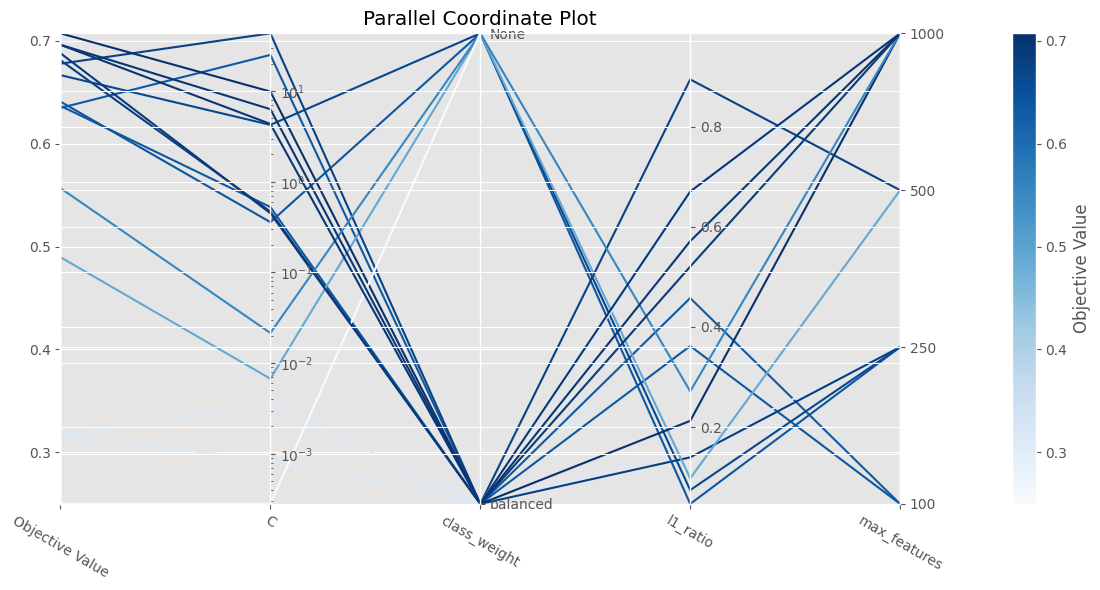

In [24]:
import optuna
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

ax = optuna.visualization.matplotlib.plot_parallel_coordinate(study_bow)

fig = ax.figure
fig.set_size_inches(12, 6)
fig.tight_layout()

fig.savefig("figures/optuna_parallel_coordinate_bow.png", dpi=150, bbox_inches="tight")

plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\4138025193.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_param_importances(study_bow)


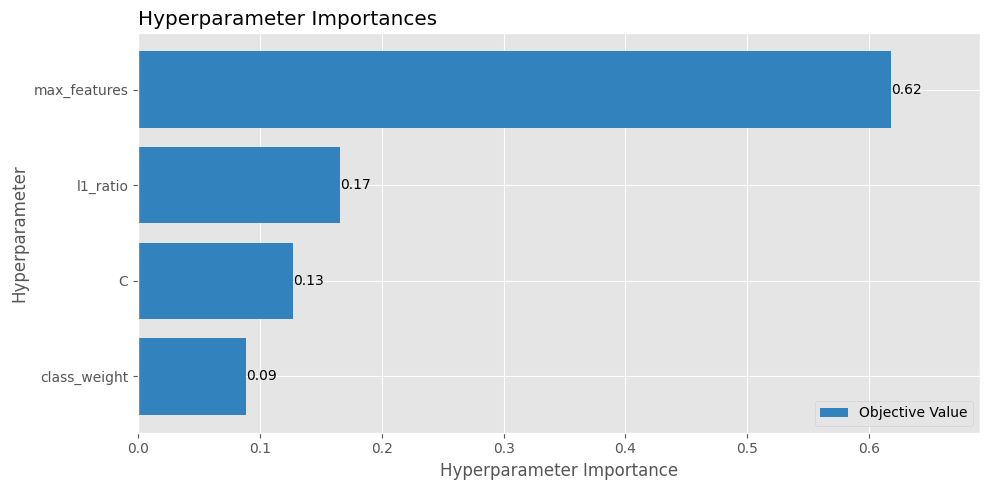

In [25]:
ax = optuna.visualization.matplotlib.plot_param_importances(study_bow)

fig = ax.figure
fig.set_size_inches(10, 5)
fig.tight_layout()

fig.savefig("figures/optuna_param_importances_bow.png", dpi=150, bbox_inches="tight")

plt.show()

In [26]:
df_trials_bow = study_bow.trials_dataframe()

df_trials_bow.sort_values("value", ascending=False)[
    [
        "value",
        "params_C",
        "params_l1_ratio",
        "params_class_weight",
        "params_max_features"
    ]
].head(10)

,value,params_C,params_l1_ratio,params_class_weight,params_max_features
1,0.707085,9.877700,0.212339,balanced,1000
14,0.695964,6.314274,0.670733,balanced,1000
13,0.695964,4.340964,0.571529,balanced,1000
12,0.687745,0.449099,0.520714,balanced,1000
2,0.680964,0.468940,0.139494,balanced,250
6,0.677591,43.350454,0.894827,balanced,500
9,0.666475,4.242502,0.074045,None,250
3,0.640761,0.358499,0.046450,None,250
11,0.636620,0.525882,0.362008,balanced,100
10,0.634626,25.064727,0.457827,balanced,100


## 3.3. Regresión Logística con Embeddings (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando Embeddings. 

- Prueba el espacio de búsqueda de la regresión lineal.
- Puedes usar `EMBEDDING_COLS` con `passthrough` para seleccionar solo los embeddings en el ColumnTransformer y descartar el resto de features.
- Utiliza unos 5 min, con 100 trials máximo.

In [17]:
class LogRegEmbeddingsExperiment(AbstractExperiment):
    """Regresión Logística usando solo embeddings."""

    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # Seleccionamos solo las columnas de embeddings.
        # Usamos passthrough porque los embeddings ya son numéricos.
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )

        model = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=3000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
Best trial: 2. Best value: 0.510307:   3%|▎         | 3/100 [00:03<01:50,  1.14s/it, 3.05/300 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Best trial: 3. Best value: 0.731625:  10%|█         | 10/100 [03:05<10:46,  7.19s/it, 185.98/300 seconds] c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-pa

Regresión_Logística__Embeddings  | Macro recall final_train=0.616  test=0.591


## 3.4. Regresión Logística con Todo (0.2 pts)

Entrena ahora una **Regresión Logística** sobre todas las features (base + BoW + embeddings). 

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Puedes usar (Puedes usar `EMBEDDING_COLS` con `passthrough` para permitir que embeddings pase sin modificaciones) a la vez que continuas usando el resto de los transformadores.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [22]:
class LogRegFullExperiment(AbstractExperiment):
    """Regresión Logística usando features base + BoW + embeddings."""

    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )

        model = LogisticRegression(
            solver="liblinear",
            penalty="l2",
            C=hparams["C"],
            class_weight=hparams["class_weight"],
            max_iter=1000,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500],
            ),
            "C": trial.suggest_float("C", 1e-3, 1e1, log=True),
            "class_weight": trial.suggest_categorical(
                "class_weight",
                [None, "balanced"],
            ),
        }


exp_executor.run_experiment(
    experiment=LogRegFullExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=10,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
Best trial: 3. Best value: 0.706019: 100%|██████████| 10/10 [00:16<00:00,  1.70s/it, 16.95/60 seconds]
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:277: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Acer\AppData\Local\Temp\ip

KeyboardInterrupt: 

Responde:

1. De los feature-sets de la Regresión Logística (`Base`, `Bow`, `Base+Bow`, `Embeddings`, `Todo`), ¿cuál funcionó mejor? ¿El texto y/o los embeddings aportan sobre lo puramente tabular? **(0.1 pts)**
2. ¿Qué conjunto de información fue el que aportó la mayor cantidad de señal al modelo? **(0.1 pts)**
3. En los experimentos `Bow` y `Base+Bow`, ¿qué pasa con `Base`? ¿Continúa siendo relevante? **(0.1 pts)**
4. ¿Combinar `Todo` superó claramente a usar solo texto o solo embeddings? ¿Qué sugiere eso sobre la redundancia de la información? **(0.1 pts)**
5. La representación `Bow` genera muchas columnas **dispersas**, mientras que los embeddings son vectores **densos** de alta dimensión (1024). ¿Por qué un modelo lineal suele desempeñarse bien en alta dimensión? **(0.1 pts)**
6. Ahora, en términos de **tiempo**, analiza la duración de cada modelo final. ¿Cuál se demoró menos? ¿Cuál más? ¿Cuál elegirías considerando no solo la métrica de evaluación, sino también la complejidad del modelo, el tiempo de entrenamiento y el tiempo de predicción? Además, considera que, para el caso de los embeddings, hay que pagar tanto tiempo de cálculo como costo por token consumido. **(0.1 pts)**
7. Abre en MLflow el run `*_search` de alguno de tus modelos y mira el artefacto `optuna_parallel_coordinate.png`. ¿Qué hiperparámetro se asocia más con un buen `macro_recall_val`? ¿En qué rangos de `C` y `l1_ratio` se concentran los mejores *trials*? ¿`class_weight="balanced"` tiende a ayudar? **(0.1 pts)**
8. El ejecutor guarda, en cada run de *refit*, el artefacto `permutation_importance_test.png` (top-20 de columnas por caída del macro recall en test). (a) En un modelo de **texto** (p. ej. `Base+Bow`), ¿qué columna de entrada domina? ¿Qué significa que permutar `Texto` derrumbe la métrica? (b) Abre ahora el de un modelo de **embeddings**: ¿qué aparece en el top-20 y qué te dice eso sobre la interpretabilidad de los embeddings? **(0.2 pts)**

_Subtotal preguntas: 0.9 pts_

**Responde aquí**

> 1. El feature-set que funcionó mejor fue BoW, con un macro_recall_test aproximado de 0.747. Este resultado supera ampliamente al modelo Base, que obtuvo cerca de 0.493. Esto muestra que el texto del ticket aporta mucha información predictiva sobre la prioridad. En cambio, las variables tabulares por sí solas no fueron suficientes para capturar adecuadamente el problema. Los embeddings también aportan respecto a Base, ya que alcanzan un macro_recall_test cercano a 0.591, pero en este caso no superan a la representación BoW.

> 2. El conjunto que aportó mayor señal fue el texto representado mediante Bag-of-Words. Esto se observa tanto en las métricas como en la permutation importance. En el modelo BoW, la variable Texto domina completamente la importancia, y al permutarla la caída del macro recall es muy grande. En Base+BoW ocurre algo similar, Texto sigue siendo la variable más importante, mientras que N_Caracteres_Ticket, Categoría_Problema y Canal_Ticket aportan mucho menos. Esto indica que el contenido escrito del reclamo contiene la mayor parte de la información útil para distinguir la prioridad del ticket.

> 3. Al comparar BoW con Base+BoW, se observa que agregar las variables base no mejora claramente el desempeño. El modelo BoW obtuvo un macro_recall_test cercano a 0.747, mientras que Base+BoW obtuvo aproximadamente 0.743. Esto sugiere que las variables base sí pueden aportar algo de información contextual, pero su contribución es pequeña frente a la señal contenida en el texto. Por lo tanto, Base no parece ser irrelevante, pero su aporte marginal es bajo cuando ya se utiliza el texto del ticket.

> 4. No, el modelo Todo, que combina variables base, BoW y embeddings, tuvo un desempeño competitivo, pero no superó claramente a BoW. Según los runs registrados, Todo quedó alrededor de 0.735–0.745 de macro_recall_test, mientras que BoW obtuvo cerca de 0.747. Esto sugiere que parte de la información de los embeddings y de las variables base puede ser redundante respecto al texto representado con BoW. También es posible que agregar muchas variables aumente la complejidad del modelo sin entregar una mejora clara en generalización. Usar solo embeddings fue inferior a BoW, el modelo de embeddings obtuvo cerca de 0.591 de macro_recall_test. Además, tuvo muy buen recall para Alta, pero muy bajo recall para Critica, lo que no es ideal para el objetivo del negocio.

> 5. Un modelo lineal puede desempeñarse bien en alta dimensión porque, en problemas de texto, cada palabra o término se transforma en una variable distinta. Esto genera muchas columnas, pero también permite que el modelo encuentre combinaciones de términos que separan bien las clases. En representaciones como BoW cada ticket usa solo una pequeña parte del vocabulario. La regresión logística puede funcionar bien en este contexto, especialmente cuando se usa regularización, porque esta ayuda a controlar el sobreajuste y a limitar el peso de variables poco relevantes. Con esto puede ser muy efectivo para clasificación de texto.

> 6. El modelo más rápido fue Base, porque utiliza pocas variables tabulares y no requiere transformar texto ni procesar embeddings. Luego vienen BoW y Base+BoW, que agregan el costo de vectorizar el texto. Los modelos con embeddings y especialmente Todo son más costosos, porque trabajan con 1024 dimensiones densas adicionales. El modelo más pesado fue Todo, ya que combina BoW, variables tabulares y embeddings. Los embeddings tienen un costo extra, para cada nuevo ticket habría que calcular el embedding, lo que implica tiempo de inferencia adicional y costo asociado al uso del modelo de embeddings.
> Considerando métrica, complejidad y costo, elegiría BoW. Tiene el mejor macro_recall_test observado, no requiere generar embeddings externos y su desempeño es claramente superior al baseline.

> 7. Para esta pregunta escogí el experimento Regresión Logística + Base+BoW. Al revisar el gráfico optuna_parallel_coordinate.png y la importancia de hiperparámetros, se observa que el parámetro más asociado a un buen macro_recall_val fue max_features, con una importancia aproximada de 0.62. Los mejores trials se concentraron principalmente en max_features = 1000, lo que sugiere que usar un vocabulario más amplio ayudó al modelo.
> Respecto a C, los mejores resultados aparecen mayormente en valores moderados-altos, aproximadamente entre 4 y 10. Para l1_ratio, los mejores trials se concentran en valores intermedios, aproximadamente entre 0.2 y 0.7. Además, class_weight="balanced" aparece en la mayoría de los mejores trials, por lo que sí parece ayudar, lo cual es consistente con el desbalance de clases del problema.

> 8(a). En el modelo Base+BoW, la columna que domina es Texto. En la permutation importance, al permutar Texto la caída del macro recall es muy grande, cercana a 0.5 en BoW. Esto significa que el modelo depende fuertemente del contenido textual del ticket para clasificar la prioridad. Si se desordena o rompe la relación entre texto y etiqueta, el desempeño cae considerablemente. 

>  8(b). En el modelo de embeddings aparecen variables como embedding_dim_218, embedding_dim_364, embedding_dim_610, embedding_dim_613, entre otras. Estas dimensiones tienen cierta importancia, pero individualmente sus caídas de macro recall son mucho más pequeñas que la importancia de Texto en BoW. Esto muestra una diferencia importante de interpretabilidad. En BoW, la variable Texto puede entenderse como el contenido del ticket, por otro lado, las dimensiones de embeddings no tienen un significado humano directo, son coordenadas latentes aprendidas por el modelo de embeddings, por lo que son más difíciles de interpretar.

---

## 3.5. Árbol de Decisión + Base+Bow (0.2 pts)

Dejamos atrás los modelos lineales y pasamos a modelos **basados en árboles**. A diferencia de la Regresión Logística, un árbol parte el espacio con cortes *axis-aligned* (mira una feature a la vez), así que es interesante ver cómo se las arregla con el mismo texto.

Entrena un **Árbol de Decisión** sobre el feature-set **`Base+Bow`** (tabular + BoW).

- Optimiza al menos `max_depth`, `min_samples_leaf` y `ccp_alpha`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"` para no descuidar las clases minoritarias.

In [27]:
from sklearn.tree import DecisionTreeClassifier

class ArbolBaseBowExperiment(AbstractExperiment):
    """Árbol de Decisión usando features base + texto con Bag-of-Words."""

    @property
    def model_name(self) -> str:
        return "Árbol_Decisión"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                # Variable numérica base
                ("Nums", "passthrough", NUM_COLS),

                # Variables categóricas base
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),

                # Texto usando Bag-of-Words
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ]
        )

        model = DecisionTreeClassifier(
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            ccp_alpha=hparams["ccp_alpha"],
            class_weight="balanced",
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [None, 5, 10, 20, 40],
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                30,
            ),
            "ccp_alpha": trial.suggest_float(
                "ccp_alpha",
                0.0,
                0.02,
            ),
        }


exp_executor.run_experiment(
    experiment=ArbolBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
Best trial: 54. Best value: 0.583785:  81%|████████  | 81/100 [02:00<00:28,  1.49s/it, 120.62/120 seconds]
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:277: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Acer\AppData\Local\Tem

Árbol_Decisión__Base+BoW         | Macro recall final_train=0.792  test=0.525


---

## 3.6. Random Forest + Base+Bow (0.2 pts)

El **Random Forest** es un ensamble por **bagging** de árboles: entrena muchos árboles sobre remuestreos (con reemplazo y submuestreo de features) y promedia/vota, reduciendo la varianza de un árbol único. Entrénalo sobre el mismo feature-set **`Base+Bow`** para compararlo contra el árbol y contra la logística.

- Optimiza al menos `n_estimators` y `max_depth`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [28]:
from sklearn.ensemble import RandomForestClassifier

class RandomForestBaseBowExperiment(AbstractExperiment):
    """Random Forest usando features base + texto con Bag-of-Words."""

    @property
    def model_name(self) -> str:
        return "Random_Forest"

    @property
    def feature_set(self) -> str:
        return "Base+BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", "passthrough", NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ]
        )

        model = RandomForestClassifier(
            n_estimators=hparams["n_estimators"],
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [100, 200, 300],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [None, 10, 20, 40],
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                10,
            ),
        }


exp_executor.run_experiment(
    experiment=RandomForestBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
Best trial: 23. Best value: 0.714021: 100%|██████████| 100/100 [02:34<00:00,  1.54s/it, 154.44/180 seconds]
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:277: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Acer\AppData\Local\Te

Random_Forest__Base+BoW          | Macro recall final_train=0.881  test=0.671


Responde:

1. ¿Qué es **bagging**? ¿Cómo reduce la varianza y por qué un Random Forest suele superar a un único árbol de decisión? **(0.1 pts)**
2. Compara el Árbol y el Random Forest contra la Regresión Logística sobre el mismo texto (`Base+Bow`). ¿Quién gana? ¿Te sorprende? **(0.1 pts)**

_Subtotal preguntas: 0.2 pts_

**Responde aquí**

> 1. El bagging es una técnica de ensamble que entrena varios modelos sobre distintas muestras aleatorias del conjunto de entrenamiento, generadas con reemplazo. Luego, combina sus predicciones mediante votación o promedio. Esto reduce la varianza, porque un árbol de decisión individual puede ser muy sensible a pequeños cambios en los datos. En cambio, Random Forest entrena muchos árboles distintos y promedia sus decisiones, haciendo que el resultado final sea más estable y menos propenso al sobreajuste. Por eso Random Forest suele superar a un único árbol de decisión, mantiene la capacidad de capturar relaciones no lineales, pero reduce la inestabilidad típica de un árbol individual.

> 2. Comparando los modelos sobre el mismo feature-set Base+BoW, los resultados fueron aproximadamente:

> Árbol de Decisión + Base+BoW:	0.52

> Random Forest + Base+BoW: 0.67

> Regresión Logística + Base+BoW: 0.74

> El Random Forest supera claramente al Árbol de Decisión, lo que confirma que el bagging ayuda a mejorar la estabilidad y el desempeño frente a un solo árbol. Sin embargo, el mejor modelo sigue siendo la Regresión Logística + Base+BoW. Esto no es raro, pues BoW genera una representación de texto de alta dimensionalidad y dispersa, donde los modelos lineales suelen funcionar muy bien. 


---

## 3.7. LightGBM + Bow (0.2 pts)

Seguimos con árboles, pero ahora con **boosting**. El **LightGBM** construye árboles de forma **secuencial**, donde cada nuevo árbol corrige los errores del conjunto anterior (ataca el *sesgo*), a diferencia del bagging del Random Forest (que ataca la *varianza*).

Entrena un **LightGBM** sobre **`Bow`** (texto disperso vía Bag of Words).

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [31]:
from lightgbm import LGBMClassifier
import numpy as np

class LgbmBowExperiment(AbstractExperiment):
    """LightGBM usando solo texto con Bag-of-Words."""

    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "BoW"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "BoW",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,   # ESTA LÍNEA SOLUCIONA EL ERROR
                    ),
                    TEXT_COL,
                ),
            ]
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [50, 100, 200, 300],
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True,
            ),
            "num_leaves": trial.suggest_categorical(
                "num_leaves",
                [15, 31, 63, 127],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.629178:   1%|          | 1/100 [00:06<10:47,  6.54s/it, 6.53/180 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning

LightGBM__BoW                    | Macro recall final_train=0.999  test=0.731


c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.8. LightGBM + Embeddings (0.2 pts)

Entrena el mismo **LightGBM** sobre **`Embeddings`** (los 1024 vectores densos), para ver cómo se comporta el boosting sobre una representación densa donde cada dimensión, por sí sola, no tiene un significado interpretable.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves` y `max_depth`.
- Usa `class_weight="balanced"`.

In [32]:
from lightgbm import LGBMClassifier

class LgbmEmbeddingsExperiment(AbstractExperiment):
    """LightGBM usando solo embeddings."""

    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [50, 100, 200, 300],
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True,
            ),
            "num_leaves": trial.suggest_categorical(
                "num_leaves",
                [15, 31, 63, 127],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.690499:   1%|          | 1/100 [00:28<47:04, 28.53s/it, 28.52/180 seconds]c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarnin

LightGBM__Embeddings             | Macro recall final_train=1.000  test=0.649


c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.9. LightGBM + Todo (0.2 pts)

Finalmente, entrena el **LightGBM** sobre **`Todo`** (tabular + BoW + embeddings) y compáralo con las dos variantes anteriores.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
import numpy as np

# Asegurar que embeddings estén en formato compatible con LightGBM
X_train[EMBEDDING_COLS] = X_train[EMBEDDING_COLS].astype("float32")
X_val[EMBEDDING_COLS] = X_val[EMBEDDING_COLS].astype("float32")
X_test[EMBEDDING_COLS] = X_test[EMBEDDING_COLS].astype("float32")


class LgbmTodoExperiment(AbstractExperiment):
    """LightGBM usando variables base + BoW + embeddings."""

    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),

                ("Cat", OneHotEncoder(
                    handle_unknown="ignore",
                    dtype=np.float32
                ), CAT_COLS),

                ("BoW", CountVectorizer(
                    tokenizer=tokenizador_stemming,
                    token_pattern=None,
                    max_features=hparams["max_features"],
                    dtype=np.float32
                ), TEXT_COL),

                ("Embeddings", "passthrough", EMBEDDING_COLS),
            ]
        )

        model = LGBMClassifier(
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [50, 100, 200, 300],
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True,
            ),
            "num_leaves": trial.suggest_categorical(
                "num_leaves",
                [15, 31, 63, 127],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmTodoExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

Responde:

1. ¿Qué es **boosting** y en qué se diferencia conceptualmente del bagging (piensa en cómo se construyen los árboles y a qué error atacan)? **(0.1 pts)**
2. **¿Es buena idea usar LightGBM directamente sobre los embeddings?** Compara `LightGBM__Embeddings` con `Regresión_Logística__Embeddings` y explica por qué un árbol puede tener dificultades con dimensiones densas e individualmente sin significado. **(0.2 pts)**
3. Para LightGBM, ¿qué feature-set resultó mejor? ¿Y comparado con la mejor Regresión Logística? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> 1. El boosting es una técnica de ensamble donde los árboles se construyen de manera secuencial, cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores. En cambio, el bagging, como Random Forest, entrena muchos árboles en paralelo sobre muestras distintas y luego combina sus predicciones. Su principal objetivo es reducir la varianza de modelos inestables, como los árboles de decisión individuales.

> 2. En este caso, LightGBM sobre embeddings funcionó mejor que la Regresión Logística sobre embeddings. LightGBM obtuvo un macro_recall_test cercano a 0.65, mientras que la Regresión Logística con embeddings obtuvo cerca de 0.59. Además, LightGBM logró un mejor recall para la clase Critica (0.48) en comparación con la Regresión Logística con embeddings, que prácticamente no detectaba bien esa clase (0.04). Usar árboles sobre embeddings no siempre es ideal, porque cada dimensión del embedding no tiene una interpretación individual clara. Los árboles hacen cortes sobre variables una a una, por lo que pueden tener dificultad para aprovechar representaciones densas donde la información está distribuida entre muchas dimensiones.

> 3. Para LightGBM, el mejor feature-set fue BoW, con un macro_recall_test aproximado de 0.73. Luego Todo, con cerca de 0.69, y finalmente Embeddings, con cerca de 0.65. Comparado con la mejor Regresión Logística, LightGBM no logró superarla. La Regresión Logística con BoW obtuvo cerca de 0.747 de macro_recall_test, levemente superior al LightGBM con BoW.
> Esto sugiere que para este problema, la representación textual tipo Bag-of-Words es la que más aporta, y que un modelo lineal sigue siendo muy competitivo sobre texto disperso.

---

## 3.10. Red Neuronal (MLP) + Embeddings (0.2 pts)

Para cerrar el barrido, y a modo **demostrativo**, entrena una red neuronal (`MLPClassifier`) **solo sobre los embeddings**. La idea es ver si una red, que opera sobre el vector completo (como el lineal), se adapta bien a una representación **densa** de 1024 dimensiones donde la información vive en la geometría del espacio.

- Optimiza la **arquitectura** (`hidden_layer_sizes`) y la **regularización** (`alpha`).
- Recuerda que puedes usar múltiples celdas.

In [42]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np


# Asegurar que los embeddings estén en formato numérico compatible
X_train[EMBEDDING_COLS] = X_train[EMBEDDING_COLS].astype("float32")
X_val[EMBEDDING_COLS] = X_val[EMBEDDING_COLS].astype("float32")
X_test[EMBEDDING_COLS] = X_test[EMBEDDING_COLS].astype("float32")


class MlpEmbeddingsExperiment(AbstractExperiment):
    """Red neuronal MLP usando solo embeddings."""

    @property
    def model_name(self) -> str:
        return "MLP"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Embeddings", StandardScaler(), EMBEDDING_COLS),
            ]
        )

        arquitecturas = {
            "64": (64,),
            "128": (128,),
            "256": (256,),
            "128_64": (128, 64),
            "256_128": (256, 128),
        }

        model = MLPClassifier(
            hidden_layer_sizes=arquitecturas[hparams["hidden_layer_sizes"]],
            alpha=hparams["alpha"],
            learning_rate_init=hparams["learning_rate_init"],
            activation="relu",
            solver="adam",
            max_iter=500,
            early_stopping=True,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "hidden_layer_sizes": trial.suggest_categorical(
                "hidden_layer_sizes",
                ["64", "128", "256", "128_64", "256_128"],
            ),
            "alpha": trial.suggest_float(
                "alpha",
                1e-5,
                1e-1,
                log=True,
            ),
            "learning_rate_init": trial.suggest_float(
                "learning_rate_init",
                1e-4,
                1e-2,
                log=True,
            ),
        }


# -------------------------------------------------------------------
# Workaround:
# El ExperimentExecutor usa np.isnan / np.isinf sobre y_pred.
# Como las predicciones son texto ("Baja", "Media", etc.), eso puede fallar.
# Este parche evita el error solo mientras se ejecuta este experimento.
# -------------------------------------------------------------------

_original_isnan = np.isnan
_original_isinf = np.isinf

def safe_isnan(x):
    try:
        return _original_isnan(x)
    except TypeError:
        return np.zeros(np.asarray(x).shape, dtype=bool)

def safe_isinf(x):
    try:
        return _original_isinf(x)
    except TypeError:
        return np.zeros(np.asarray(x).shape, dtype=bool)

np.isnan = safe_isnan
np.isinf = safe_isinf

try:
    study_mlp_embeddings = exp_executor.run_experiment(
        experiment=MlpEmbeddingsExperiment(),
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        timeout_seconds=180,
        n_trials=50,
    )
finally:
    # Restaurar numpy para no afectar otros experimentos
    np.isnan = _original_isnan
    np.isinf = _original_isinf

C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:235: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:248: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()
Best trial: 38. Best value: 0.788885: 100%|██████████| 50/50 [02:05<00:00,  2.51s/it, 125.67/180 seconds]
C:\Users\Acer\AppData\Local\Temp\ipykernel_4184\3226529092.py:277: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Acer\AppData\Local\Temp

MLP__Embeddings                  | Macro recall final_train=0.970  test=0.743


Responde:

1. ¿La red neuronal se adapta bien a los embeddings? Compárala con la Regresión Logística y el LightGBM sobre embeddings. **(0.1 pts)**
2. `MLPClassifier` no tiene `class_weight`. ¿Cómo podría afectar esto al macro recall dado el desbalance? ¿Qué alternativas tendrías para manejar el desbalance en una red? **(0.2 pts)**
3. En términos de **costo computacional** y **cantidad de hiperparámetros**, ¿qué desventaja tiene la red frente al modelo lineal sobre estos mismos embeddings? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

> 1. La red neuronal se adapta bien a los embeddings. El modelo MLP__Embeddings obtuvo un macro_recall_test de aproximadamente 0.743, superando tanto a la Regresión_Logística__Embeddings cercana a 0.59, como a LightGBM__Embeddings, que obtuvo cerca de 0.65. Además, la MLP logró un buen desempeño en la clase minoritaria Critica, con un recall de aproximadamente 0.59, mejor que LightGBM con embeddings y mucho mejor que la regresión logística con embeddings. Esto sugiere que la red logra aprovechar mejor la representación densa de los embeddings.7

> 2. Como MLPClassifier no tiene class_weight, el modelo no puede ponderar directamente las clases minoritarias durante el entrenamiento. Esto podría afectar el macro recall, porque las clases con menos ejemplos, como Critica, podrían recibir menos atención que clases más frecuentes como Baja o Media.

> Para manejar el desbalance en una red se podrían usar alternativas como:
* aumentar artificialmente la presencia de ejemplos de las clases con menos datos
* reducir la cantidad de ejemplos de las clases más frecuentes para equilibrar el entrenamiento
* ajustar la forma en que se decide la clase final, priorizando no descuidar categorías importantes como Critica
> En este caso del laboratorio, aun sin class_weight, la MLP logró buen desempeño en Critica, pero sigue siendo una limitación importante del modelo.

> 3. La principal desventaja de la red neuronal frente a un modelo lineal es su mayor costo computacional y la mayor cantidad de hiperparámetros a ajustar. En la MLP hay que definir arquitectura, número de capas, tamaño de capas, regularización, tasa de aprendizaje y otros parámetros de entrenamiento.

---

# Sección 4 - Selección del Mejor Modelo y Exportación — (1.0 pts)

Ya tenemos todos los experimentos registrados en MLflow. Ahora:

1. Ejecuta el siguiente código para recuerar y comparar los runs con `mlflow.search_runs` y un gráfico.
2. Elige el mejor modelo según el **macro recall en val** - NO EN **TEST**.
3. Revisa el desempeño en **test** del modelo elegido (`classification_report` + matriz de confusión), mirando en especial a `Critica`.

In [43]:
runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

# Runs de búsqueda: mejor macro recall en VAL por combinación.
search = runs[runs["tags.stage"] == "optuna_search"][["tags.study_name", "metrics.best_macro_recall_val"]].rename(
    columns={"tags.study_name": "study_name", "metrics.best_macro_recall_val": "macro_recall_val"}
)
# Runs de refit: macro recall en TEST y recall de la clase Critica.
refit = runs[runs["tags.stage"] == "refit_final"][
    ["tags.study_name", "metrics.macro_recall_test", "metrics.recall_test_Critica"]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla = (
    search.merge(refit, on="study_name", how="inner")
    .sort_values("macro_recall_val", ascending=False)
    .reset_index(drop=True)
)
display(tabla)


mejor = tabla.iloc[0]
print("Mejor modelo (por macro recall en val):", mejor["study_name"])
print("  macro_recall_val   :", round(mejor["macro_recall_val"], 3))
print("  macro_recall_test  :", round(mejor["macro_recall_test"], 3))
print("  recall_test_Critica:", round(mejor["recall_test_Critica"], 3))

,study_name,macro_recall_val,macro_recall_test,recall_test_Critica
0,MLP__Embeddings,0.788885,0.743160,0.592593
1,Regresión_Logística__Embeddings,0.741005,0.590648,0.037037
2,LightGBM__BoW,0.729748,0.730630,0.444444
3,Regresión_Logística__Todo,0.728880,0.745451,0.592593
4,Regresión_Logística__Todo,0.728880,0.735177,0.555556
5,Regresión_Logística__Todo,0.728880,0.735177,0.555556
6,Regresión_Logística__Todo,0.728880,0.745451,0.592593
7,Regresión_Logística__Todo,0.728880,0.713461,0.518519
8,Regresión_Logística__Todo,0.728880,0.683397,0.518519
9,Regresión_Logística__Base+BoW,0.728880,0.742712,0.592593


Mejor modelo (por macro recall en val): MLP__Embeddings
  macro_recall_val   : 0.789
  macro_recall_test  : 0.743
  recall_test_Critica: 0.593


Macro recall (test): 0.743
              precision    recall  f1-score   support

        Alta       0.70      0.64      0.67        70
        Baja       0.90      0.88      0.89       145
     Critica       0.59      0.59      0.59        27
       Media       0.81      0.85      0.83       158

    accuracy                           0.81       400
   macro avg       0.75      0.74      0.75       400
weighted avg       0.81      0.81      0.81       400



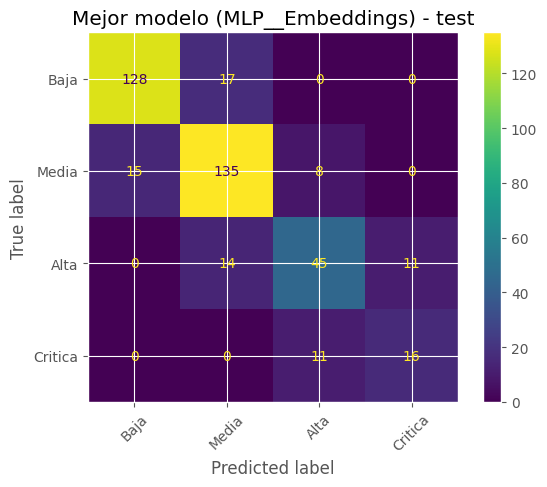

In [44]:
# Recuperamos el run de refit del mejor modelo (su pipeline ya entrenada con train+val).
mejor_refit = runs[(runs["tags.stage"] == "refit_final") & (runs["tags.study_name"] == mejor["study_name"])].iloc[0]
mejor_modelo = mlflow.sklearn.load_model(f"runs:/{mejor_refit['run_id']}/model")

# Evaluación FINAL en test del modelo elegido.
pred_test = mejor_modelo.predict(X_test)
print("Macro recall (test):", round(recall_score(y_test, pred_test, average="macro"), 3))
print(classification_report(y_test, pred_test))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=ORDEN_CLASES, xticks_rotation=45)
plt.title(f"Mejor modelo ({mejor['study_name']}) - test")
plt.show()

Guarda ahora el modelo para utilizarlo en la siguiente fase

In [45]:
import cloudpickle

# El pipeline elegido contiene un tokenizador propio (y se cargó "por valor" desde MLflow),
# así que lo serializamos con cloudpickle para que el artefacto quede autocontenido y portable.
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(mejor_modelo, f)

with mlflow.start_run(run_name=f"modelo_final_{mejor['study_name']}"):
    mlflow.set_tag("stage", "modelo_final")
    mlflow.log_param("modelo_elegido", mejor["study_name"])
    mlflow.log_metric("macro_recall_test", float(recall_score(y_test, pred_test, average="macro")))
    # cloudpickle evita el serializador estricto (skops) que rechaza el tokenizador propio
    mlflow.sklearn.log_model(mejor_modelo, name="modelo_final", serialization_format="cloudpickle")
print("Modelo exportado a modelo_final.pkl")

2026/07/10 21:37:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modelo exportado a modelo_final.pkl


Responde:

1. ¿Por qué el conjunto de **test** se lee recién al final y la selección se hace por `macro_recall_val`? **(0.2 pts)**
2. Además de la métrica, ¿qué otros criterios considerarías para elegir el modelo de **producción**? En particular: si el mejor modelo usa **embeddings**, ¿qué implica eso en inferencia (pista: hay que llamar a la API de `gemini-embedding-001`)? **(0.2 pts)**
3. Mira el desempeño **por clase** en test, especialmente `Critica`. ¿El modelo sirve para el objetivo de negocio (priorizar bien los tickets críticos)? **(0.2 pts)**
4. ¿Qué información registrarías en MLflow para que este modelo sea **reproducible y desplegable** por otra persona del equipo? **(0.2 pts)**
5. Mirando todo el barrido, ¿el mejor modelo justifica su complejidad frente a alternativas más simples? ¿Cuál llevarías tú a producción y por qué? **(0.2 pts)**

_Subtotal preguntas: 1.0 pts_

**Responde aquí**

> 1. El conjunto de test se usa solo al final porque debe representar datos completamente no vistos. Si lo usamos durante la búsqueda o selección de modelos, estaríamos espiando el test y el resultado final dejaría de ser una evaluación imparcial. Por eso la selección se hace con macro_recall_val, y recién después se evalúa el modelo elegido en test.

> 2. Consideraría tiempo de entrenamiento, tiempo de predicción, costo computacional, facilidad de despliegue, estabilidad del modelo e interpretabilidad. En este caso, el mejor modelo por validación fue MLP__Embeddings, por lo que en producción habría que generar embeddings para cada nuevo ticket usando gemini-embedding-001, esto implica una llamada adicional a una API, posible costo por uso y dependencia de un servicio externo antes de poder clasificar el ticket.

> 3. El modelo MLP__Embeddings tiene un macro_recall_test de 0.743 y un recall para Critica de 0.593. Esto significa que detecta cerca del 59% de los tickets críticos. En la matriz de confusión, de 27 tickets críticos, clasifica correctamente 16 y confunde 11 como Alta. 
> Por lo tanto, el modelo sí aporta para priorizar tickets críticos, pero no es perfecto. Para el negocio, podría servir como apoyo inicial, aunque sería recomendable revisar manualmente los casos clasificados como Alta, porque ahí pueden quedar algunos tickets que sean críticos.

> 4. Registraría los hiperparámetros del modelo, la métrica usada para selección (macro_recall_val), las métricas finales en test, las métricas por clase, la matriz de confusión, el classification report, la semilla usada, el split train/val/test, el pipeline completo de preprocesamiento y el modelo final exportado. Además, como este modelo usa embeddings, también registraría el modelo de embeddings usado (gemini-embedding-001) y la versión de librerías, para que otra persona pueda reproducir y desplegar el mismo flujo.

> 5. Aunque MLP__Embeddings fue el mejor modelo según macro_recall_val (0.789) y tuvo buen desempeño en test (0.743), no necesariamente justifica toda su complejidad. Su resultado en test es muy parecido al de modelos más simples como Regresión_Logística__BoW, que obtuvo cerca de 0.747 de macro_recall_test y también un recall para Critica cercano a 0.593. Yo llevaría a producción Regresión Logística + BoW. Tiene desempeño igual o incluso levemente mejor en test, es más simple, más rápida, más interpretable y no requiere llamar a una API externa para generar embeddings. Esto la hace más conveniente para un primer despliegue en producción.
